In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

PROJ = Path.cwd().parents[0]
DATA_PROCESSED = PROJ / "data" / "processed"
MODELS_DIR = PROJ / "models"
MODELS_DIR.mkdir(exist_ok=True)

# Load processed data
X_train = np.load(DATA_PROCESSED / "X_train.npy")
X_val   = np.load(DATA_PROCESSED / "X_val.npy")
X_test  = np.load(DATA_PROCESSED / "X_test.npy")
y_train = pd.read_csv(DATA_PROCESSED / "y_train.csv").squeeze()
y_val   = pd.read_csv(DATA_PROCESSED / "y_val.csv").squeeze()
y_test  = pd.read_csv(DATA_PROCESSED / "y_test.csv").squeeze()

print("Data loaded:", X_train.shape, y_train.shape)


Data loaded: (350, 377) (350,)


In [2]:
pip install seaborn


  Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\chathudu sahassara\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [4]:
def train_and_evaluate(model, name):
    model.fit(X_train, y_train)
    preds_val = model.predict(X_val)

    acc  = accuracy_score(y_val, preds_val)
    f1   = f1_score(y_val, preds_val, average="weighted")

    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.3f} | Weighted F1: {f1:.3f}")
    print(classification_report(y_val, preds_val))

    # confusion matrix
    cm = confusion_matrix(y_val, preds_val)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} – Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return acc, f1


--- Logistic Regression ---
Accuracy: 0.787 | Weighted F1: 0.796
                     precision    recall  f1-score   support

    Mild Depression       0.30      0.43      0.35         7
Moderate Depression       0.50      0.33      0.40         3
      No Depression       0.92      0.82      0.87        57
  Severe Depression       0.67      1.00      0.80         8

           accuracy                           0.79        75
          macro avg       0.60      0.65      0.61        75
       weighted avg       0.82      0.79      0.80        75



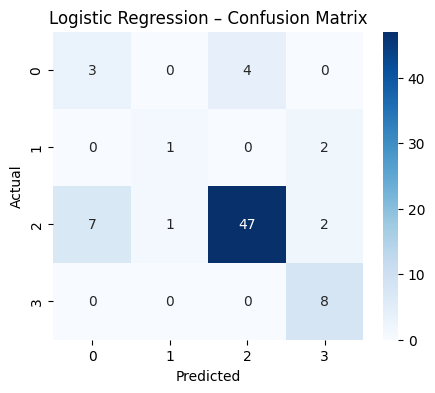

--- Random Forest ---
Accuracy: 0.853 | Weighted F1: 0.792
                     precision    recall  f1-score   support

    Mild Depression       0.00      0.00      0.00         7
Moderate Depression       0.00      0.00      0.00         3
      No Depression       0.85      1.00      0.92        57
  Severe Depression       0.88      0.88      0.88         8

           accuracy                           0.85        75
          macro avg       0.43      0.47      0.45        75
       weighted avg       0.74      0.85      0.79        75



c:\Users\chathudu sahassara\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chathudu sahassara\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chathudu sahassara\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

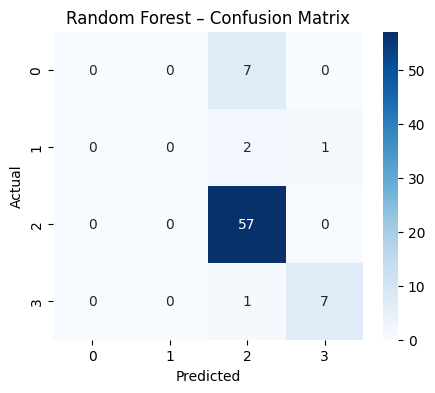

--- Gradient Boosting ---
Accuracy: 0.853 | Weighted F1: 0.795
                     precision    recall  f1-score   support

    Mild Depression       0.00      0.00      0.00         7
Moderate Depression       0.00      0.00      0.00         3
      No Depression       0.89      0.98      0.93        57
  Severe Depression       0.67      1.00      0.80         8

           accuracy                           0.85        75
          macro avg       0.39      0.50      0.43        75
       weighted avg       0.75      0.85      0.79        75



c:\Users\chathudu sahassara\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chathudu sahassara\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chathudu sahassara\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

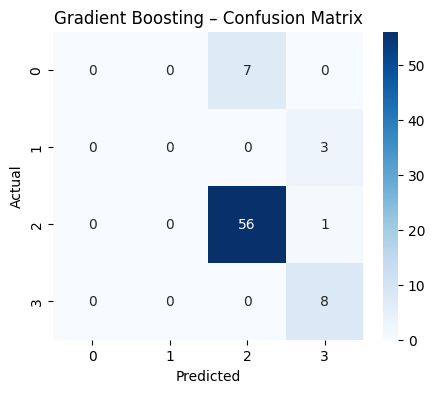

{'LogisticRegression': (0.7866666666666666, 0.795755991285403),
 'RandomForest': (0.8533333333333334, 0.7920430107526881),
 'GradientBoosting': (0.8533333333333334, 0.7946666666666666)}

In [5]:
results = {}

# Logistic Regression
log_reg = LogisticRegression(max_iter=2000, class_weight="balanced")
results["LogisticRegression"] = train_and_evaluate(log_reg, "Logistic Regression")

# Random Forest
rf = RandomForestClassifier(
    n_estimators=200, random_state=42, class_weight="balanced", n_jobs=-1
)
results["RandomForest"] = train_and_evaluate(rf, "Random Forest")

# Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
results["GradientBoosting"] = train_and_evaluate(gb, "Gradient Boosting")

results


In [6]:
best_model_name = max(results, key=lambda k: results[k][1])  # pick by F1
print("Best model:", best_model_name)

if best_model_name == "LogisticRegression":
    best_model = log_reg
elif best_model_name == "RandomForest":
    best_model = rf
else:
    best_model = gb

# retrain on train + val combined for stronger model
X_train_full = np.concatenate([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])
best_model.fit(X_train_full, y_train_full)

# evaluate on test set
preds_test = best_model.predict(X_test)
acc = accuracy_score(y_test, preds_test)
f1  = f1_score(y_test, preds_test, average="weighted")
print(f"Test Accuracy = {acc:.3f}, Weighted F1 = {f1:.3f}")
print(classification_report(y_test, preds_test))


Best model: LogisticRegression
Test Accuracy = 0.711, Weighted F1 = 0.738
                     precision    recall  f1-score   support

    Mild Depression       0.14      0.29      0.19         7
Moderate Depression       0.60      1.00      0.75         3
      No Depression       0.89      0.71      0.79        58
  Severe Depression       0.73      1.00      0.84         8

           accuracy                           0.71        76
          macro avg       0.59      0.75      0.64        76
       weighted avg       0.79      0.71      0.74        76



In [7]:
model_path = MODELS_DIR / f"{best_model_name}_depression_model.joblib"
joblib.dump(best_model, model_path)
print("Model saved to:", model_path)


Model saved to: d:\Git\DepressionLevel\DepressionModelProject\models\LogisticRegression_depression_model.joblib
